# Hotel Booking Demand Analysis

## Business Problem

Hotels need to understand customer booking behavior to reduce cancellations, improve revenue management, and optimize operational planning.

High cancellation rates can create uncertainty in hotel occupancy and revenue forecasting. By analyzing historical booking data, hotels can identify cancellation patterns and customer trends to make better decisions.

## Objectives

This project aims to:

- Clean and prepare hotel booking data for analysis.
- Analyze booking cancellation patterns.
- Understand customer booking behavior.
- Compare City Hotels and Resort Hotels.
- Analyze booking channels and customer segments.
- Evaluate the revenue impact of cancellations.
- Generate business recommendations based on data insights.

## Dataset

**Dataset:** Hotel Booking Demand Dataset (Kaggle)

The dataset contains hotel reservation information including:

- Hotel type
- Booking details
- Customer information
- Cancellation status
- Pricing information
- Distribution channels
- Reservation characteristics

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Author

Arista Kayirangwa 

# 1. Import Libraries

The following Python libraries are used for data loading, cleaning, analysis, and visualization.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when viewing datasets
pd.set_option('display.max_columns', None)

# Visualization style
sns.set_style("whitegrid")

# 2. Load Dataset

The dataset contains hotel reservation records from City Hotels and Resort Hotels.

In this section, we load the dataset and inspect the first rows to understand its structure.

In [4]:
df = pd.read_csv("hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
print(df.shape)

(119390, 32)


# 3. Initial Data Exploration

Before cleaning the dataset, we inspect its structure, data types, and summary statistics to understand the information available.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# 4. Data Cleaning

Data cleaning is performed to improve data quality before analysis.

The cleaning steps include:

- Handling missing values.
- Removing duplicate records.
- Removing columns with excessive missing values.
- Creating a clean dataset for further analysis.

In [9]:
df_clean = df.copy()

df_clean.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [10]:
missing_values = df_clean.isnull().sum()

missing_values[missing_values > 0]

children         4
country        488
agent        16340
company     112593
dtype: int64

### Removing the Company Column

The company column contains a large number of missing values, so it is removed because it provides limited information for this analysis.

In [11]:
df_clean.drop('company', axis=1, inplace=True)

df_clean.shape

(119390, 31)

### Handling Missing Values

The remaining missing values are reviewed and replaced with appropriate values to keep the dataset complete and ready for analysis.

In [12]:
df_clean['children'] = df_clean['children'].fillna(0)

df_clean['country'] = df_clean['country'].fillna('Unknown')

df_clean['agent'] = df_clean['agent'].fillna(0)

In [13]:
df_clean.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

### Removing Duplicate Records

Duplicate bookings can affect analysis results, so duplicate records are removed to improve data accuracy.

In [14]:
df_clean.duplicated().sum()

32001

### Removing Duplicate Records

Duplicate records are removed to prevent repeated bookings from affecting the analysis results.

In [15]:
df_clean = df_clean.drop_duplicates()

df_clean.shape

(87389, 31)

In [16]:
df_clean.isnull().sum().sum()

0

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to identify patterns, trends, and relationships within hotel booking data.

The analysis focuses on:
- Booking cancellations.
- Hotel performance.
- Customer behavior.
- Booking channels.
- Revenue impact.

## 5.1 Booking Cancellation Analysis

Understanding cancellation patterns helps hotels improve occupancy planning and reduce revenue uncertainty.

In [17]:
cancellation_rate = (
    df_clean['is_canceled']
    .value_counts(normalize=True) * 100
)

cancellation_rate

is_canceled
0    72.507982
1    27.492018
Name: proportion, dtype: float64

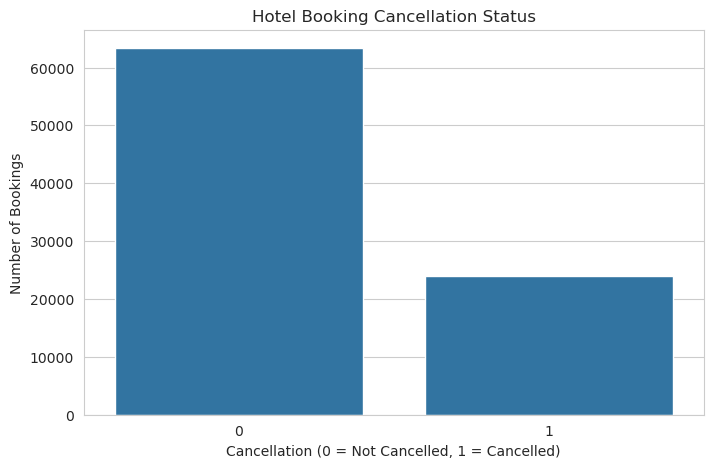

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='is_canceled'
)

plt.title("Hotel Booking Cancellation Status")
plt.xlabel("Cancellation (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Number of Bookings")

plt.show()

## 5.2 Hotel Type Analysis

This section compares booking distribution and performance between City Hotels and Resort Hotels.

In [19]:
hotel_bookings = df_clean['hotel'].value_counts()

hotel_bookings

hotel
City Hotel      53426
Resort Hotel    33963
Name: count, dtype: int64

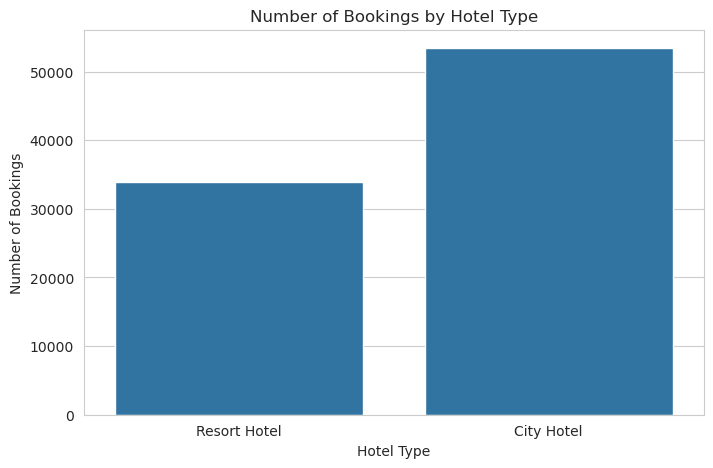

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='hotel'
)

plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

In [21]:
adr_by_hotel = (
    df_clean.groupby('hotel')['adr']
    .mean()
)

adr_by_hotel

hotel
City Hotel      110.985270
Resort Hotel     99.030296
Name: adr, dtype: float64

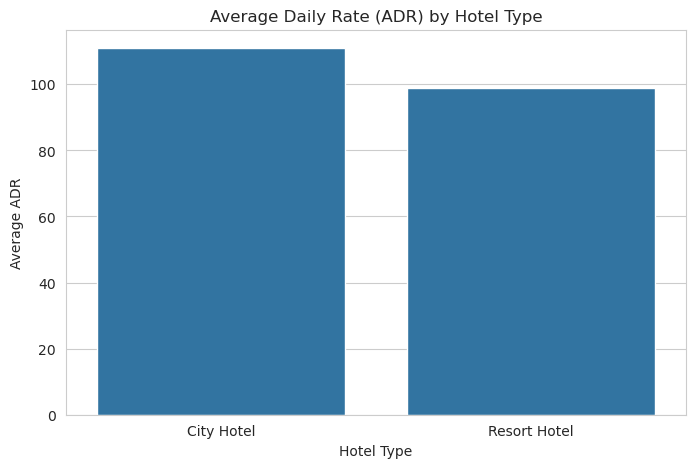

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=adr_by_hotel.index,
    y=adr_by_hotel.values
)

plt.title("Average Daily Rate (ADR) by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")

plt.show()

## 5.3 Lead Time Analysis

Lead time represents the number of days between booking creation and the arrival date.

Analyzing lead time helps identify whether customers who book earlier are more likely to cancel.

In [23]:
lead_time_cancellation = (
    df_clean.groupby('is_canceled')['lead_time']
    .mean()
)

lead_time_cancellation

is_canceled
0     70.106543
1    105.719251
Name: lead_time, dtype: float64

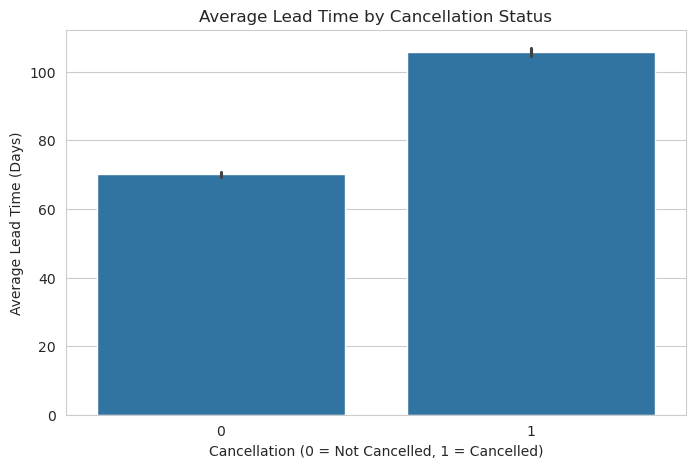

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='is_canceled',
    y='lead_time'
)

plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancellation (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Average Lead Time (Days)")

plt.show()

### Finding

Bookings that were cancelled had a higher average lead time compared to bookings that were not cancelled.

### Interpretation

Customers who make reservations far in advance may have a higher chance of changing their plans.

### Recommendation

Hotels can reduce cancellation risks by:
- Sending reminders before arrival dates.
- Monitoring long lead-time reservations.
- Creating balanced cancellation policies.

## 5.4 Monthly Booking Trends

Analyzing booking trends by month helps hotels understand seasonal demand and improve staffing, pricing, and operational planning.

In [25]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_bookings = (
    df_clean['arrival_date_month']
    .value_counts()
    .reindex(month_order)
)

monthly_bookings

arrival_date_month
January       4693
February      6097
March         7513
April         7908
May           8354
June          7765
July         10056
August       11257
September     6689
October       6934
November      4993
December      5130
Name: count, dtype: int64

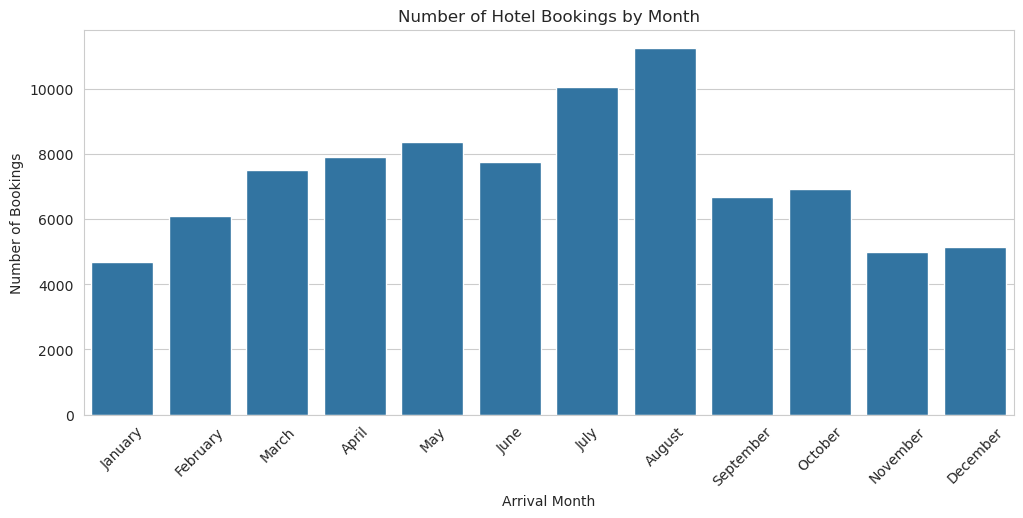

In [26]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_bookings.index,
    y=monthly_bookings.values
)

plt.title("Number of Hotel Bookings by Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.show()

### Finding

Booking demand varies throughout the year, with higher booking volumes during peak months.

### Interpretation

Seasonal patterns influence hotel demand. Understanding these trends helps hotels prepare resources and adjust pricing strategies.

### Recommendation

Hotels should:
- Increase staffing during high-demand periods.
- Create promotions during lower-demand months.
- Adjust pricing based on seasonal demand.

## 5.5 Average Daily Rate (ADR) Analysis

Average Daily Rate (ADR) is analyzed to understand pricing patterns and differences in hotel revenue performance.

In [27]:
average_adr = (
    df_clean.groupby('hotel')['adr']
    .mean()
)

average_adr

hotel
City Hotel      110.985270
Resort Hotel     99.030296
Name: adr, dtype: float64

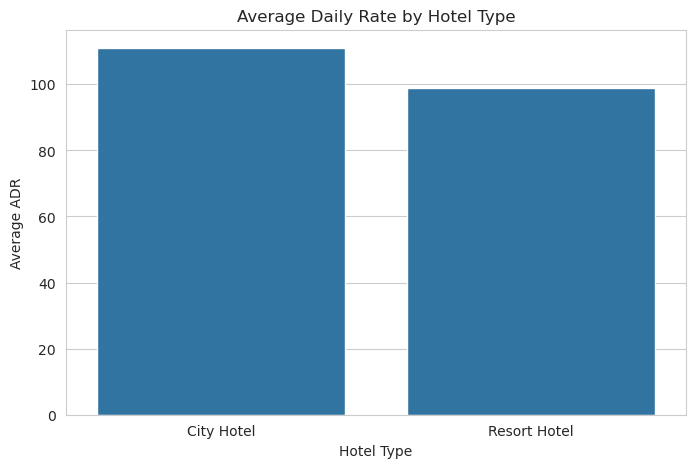

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=average_adr.index,
    y=average_adr.values
)

plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")

plt.show()

### Finding

Resort Hotels have a lower average daily rate compared with City Hotels.

### Interpretation

Although Resort Hotels usually target leisure travelers, the average room price can vary depending on season, demand, and customer segment.

### Recommendation

Hotels should:
- Monitor pricing patterns by season.
- Use demand-based pricing strategies.
- Adjust offers based on customer behavior.

## 5.6 Market Segment Analysis

Market segment analysis helps identify the main sources of hotel bookings and understand customer acquisition patterns.

In [29]:
market_segment = (
    df_clean['market_segment']
    .value_counts()
)

market_segment

market_segment
Online TA        51615
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4208
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

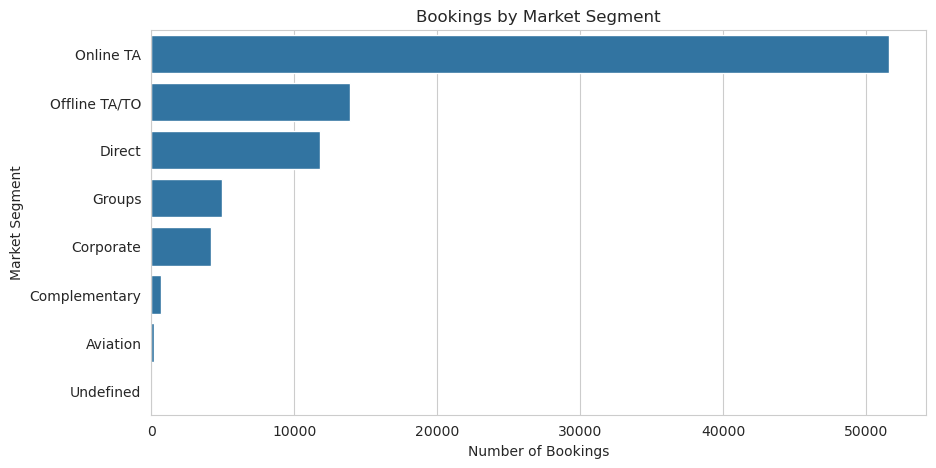

In [30]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=market_segment.values,
    y=market_segment.index
)

plt.title("Bookings by Market Segment")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")

plt.show()

### Finding

Online Travel Agencies (Online TA) represent the largest source of bookings, followed by Offline Travel Agencies and Tour Operators.

### Interpretation

Online platforms play an important role in attracting customers and generating hotel reservations.

### Recommendation

Hotels should:
- Maintain strong relationships with online travel platforms.
- Analyze commission costs from third-party channels.
- Encourage direct bookings through loyalty programs and promotions.

## 5.7 Distribution Channel Analysis

Distribution channels show the methods used by customers to make hotel reservations.

Understanding these channels helps hotels evaluate marketing strategies and booking sources.

In [31]:
distribution_channel = (
    df_clean['distribution_channel']
    .value_counts()
)

distribution_channel

distribution_channel
TA/TO        69138
Direct       12988
Corporate     5077
GDS            181
Undefined        5
Name: count, dtype: int64

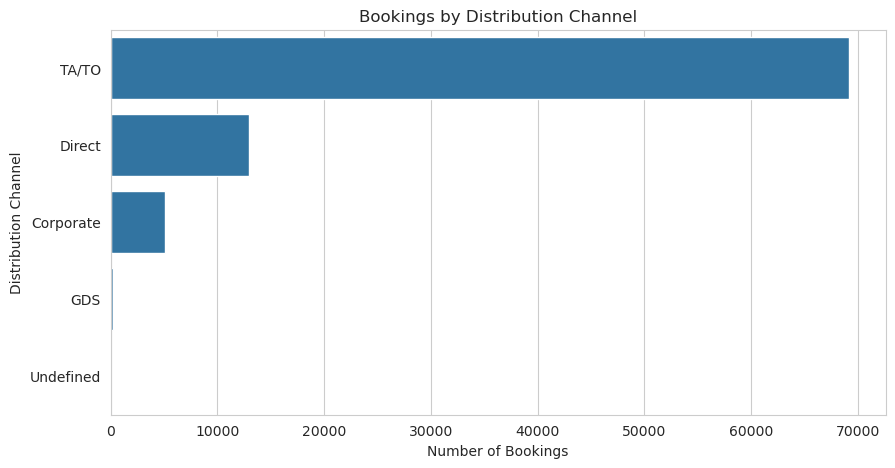

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=distribution_channel.values,
    y=distribution_channel.index
)

plt.title("Bookings by Distribution Channel")
plt.xlabel("Number of Bookings")
plt.ylabel("Distribution Channel")

plt.show()

### Finding

Travel Agencies and Tour Operators (TA/TO) are the dominant distribution channel.

### Interpretation

Most customers use third-party booking channels rather than booking directly with hotels.

### Recommendation

Hotels should:
- Maintain effective partnerships with travel agencies.
- Encourage direct bookings to reduce dependency on third-party commissions.
- Improve loyalty programs to increase returning customers.

## 5.8 Customer Type Analysis

Customer type analysis helps identify the main groups of hotel guests and understand customer behavior patterns.

In [33]:
customer_type = (
    df_clean['customer_type']
    .value_counts()
)

customer_type

customer_type
Transient          71982
Transient-Party    11724
Contract            3139
Group                544
Name: count, dtype: int64

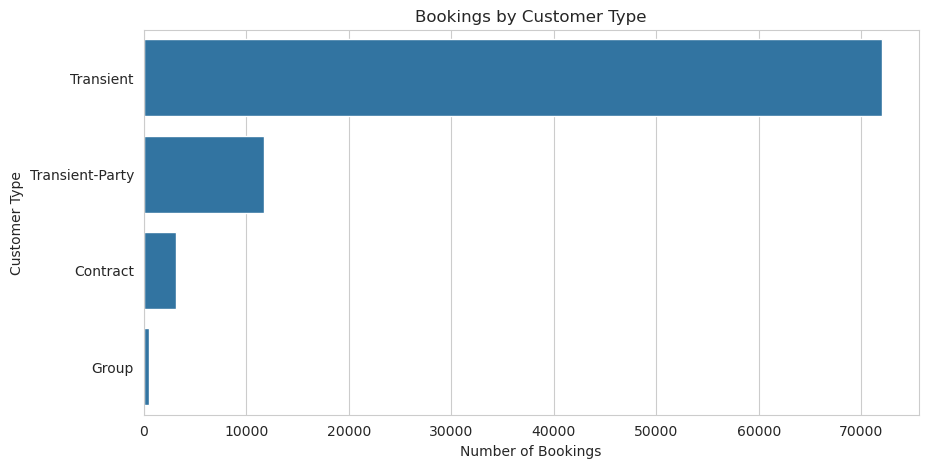

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=customer_type.values,
    y=customer_type.index
)

plt.title("Bookings by Customer Type")
plt.xlabel("Number of Bookings")
plt.ylabel("Customer Type")

plt.show()

### Finding

Transient customers represent the largest customer group, while group and contract customers represent smaller segments.

### Interpretation

Most bookings come from individual travelers rather than long-term contracts or organized groups.

### Recommendation

Hotels should:
- Develop loyalty programs for individual travelers.
- Create packages for group customers.
- Maintain relationships with corporate and contract clients.

## 5.9 Guest Country Analysis

Analyzing guest countries helps hotels understand their international customer base and improve marketing strategies for different markets.

In [35]:
top_countries = (
    df_clean['country']
    .value_counts()
    .head(10)
)

top_countries

country
PRT    27449
GBR    10432
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

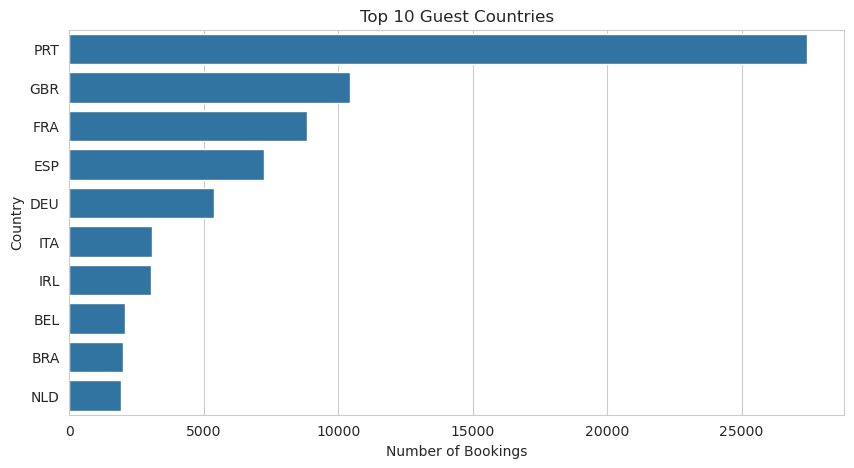

In [36]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Guest Countries")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")

plt.show()

### Finding

The majority of guests come from a small number of countries, with Portugal, the United Kingdom, France, and Spain representing some of the largest markets.

### Interpretation

Understanding guest origins helps hotels identify important customer markets and adjust marketing strategies.

### Recommendation

Hotels should:
- Target promotions toward high-demand countries.
- Offer services that match international guest needs.
- Analyze travel patterns by market.

## 5.10 Repeat Guest Analysis

Repeat guests are important because they indicate customer loyalty and satisfaction.

This analysis compares returning guests with new guests.

In [37]:
repeat_guest = (
    df_clean['is_repeated_guest']
    .value_counts()
)

repeat_guest

is_repeated_guest
0    83974
1     3415
Name: count, dtype: int64

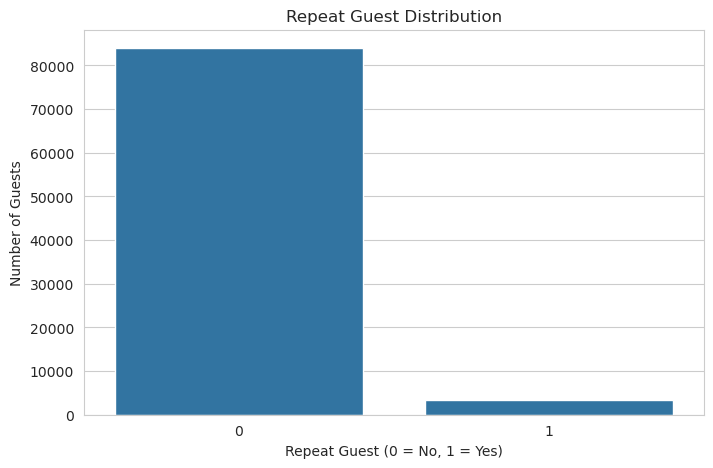

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=repeat_guest.index,
    y=repeat_guest.values
)

plt.title("Repeat Guest Distribution")
plt.xlabel("Repeat Guest (0 = No, 1 = Yes)")
plt.ylabel("Number of Guests")

plt.show()

### Finding

The majority of bookings come from new guests, while repeat guests represent a smaller proportion of reservations.

### Interpretation

The low number of repeat guests suggests that hotels have opportunities to improve customer retention and loyalty.

### Recommendation

Hotels should:
- Develop loyalty programs.
- Offer incentives for returning customers.
- Collect guest feedback to improve satisfaction.

## 5.11 Revenue Impact Analysis

Cancellations can directly affect hotel revenue. This section estimates revenue associated with cancelled and completed bookings.

In [39]:
df_clean['estimated_revenue'] = (
    df_clean['adr'] *
    df_clean['stays_in_week_nights'] +
    df_clean['adr'] *
    df_clean['stays_in_weekend_nights']
)

revenue_by_status = (
    df_clean.groupby('is_canceled')['estimated_revenue']
    .sum()
)

revenue_by_status

is_canceled
0    22976311.33
1    11484042.98
Name: estimated_revenue, dtype: float64

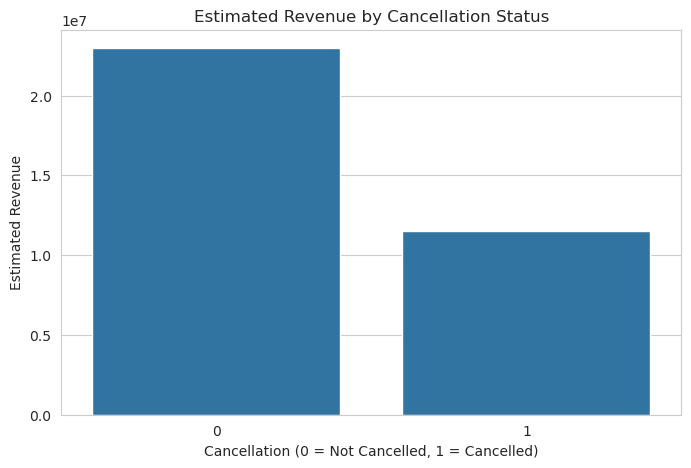

In [40]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_by_status.index,
    y=revenue_by_status.values
)

plt.title("Estimated Revenue by Cancellation Status")
plt.xlabel("Cancellation (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Estimated Revenue")

plt.show()

### Finding

Cancelled reservations represent a significant potential revenue loss for hotels.

### Interpretation

High cancellation levels create uncertainty because rooms may remain empty after cancellations, reducing expected revenue.

### Recommendation

Hotels should:
- Monitor high-risk reservations.
- Use reminder communications before arrival.
- Apply cancellation policies that balance customer flexibility and revenue protection.

## 5.12 Correlation Analysis

Correlation analysis helps identify relationships between numerical variables such as lead time, prices, stays, and cancellation status.

A correlation value close to 1 or -1 indicates a stronger relationship, while values close to 0 indicate a weaker relationship.

In [41]:
numeric_columns = df_clean.select_dtypes(include=np.number)

correlation = numeric_columns.corr()

correlation['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.184772
estimated_revenue                 0.139453
adr                               0.127974
arrival_date_year                 0.088021
stays_in_week_nights              0.082886
adults                            0.081775
children                          0.067355
stays_in_weekend_nights           0.060159
previous_cancellations            0.051464
arrival_date_day_of_month         0.005317
days_in_waiting_list              0.004461
arrival_date_week_number          0.001469
agent                            -0.000920
babies                           -0.020548
previous_bookings_not_canceled   -0.052160
is_repeated_guest                -0.089654
booking_changes                  -0.093664
total_of_special_requests        -0.120567
required_car_parking_spaces      -0.184224
Name: is_canceled, dtype: float64

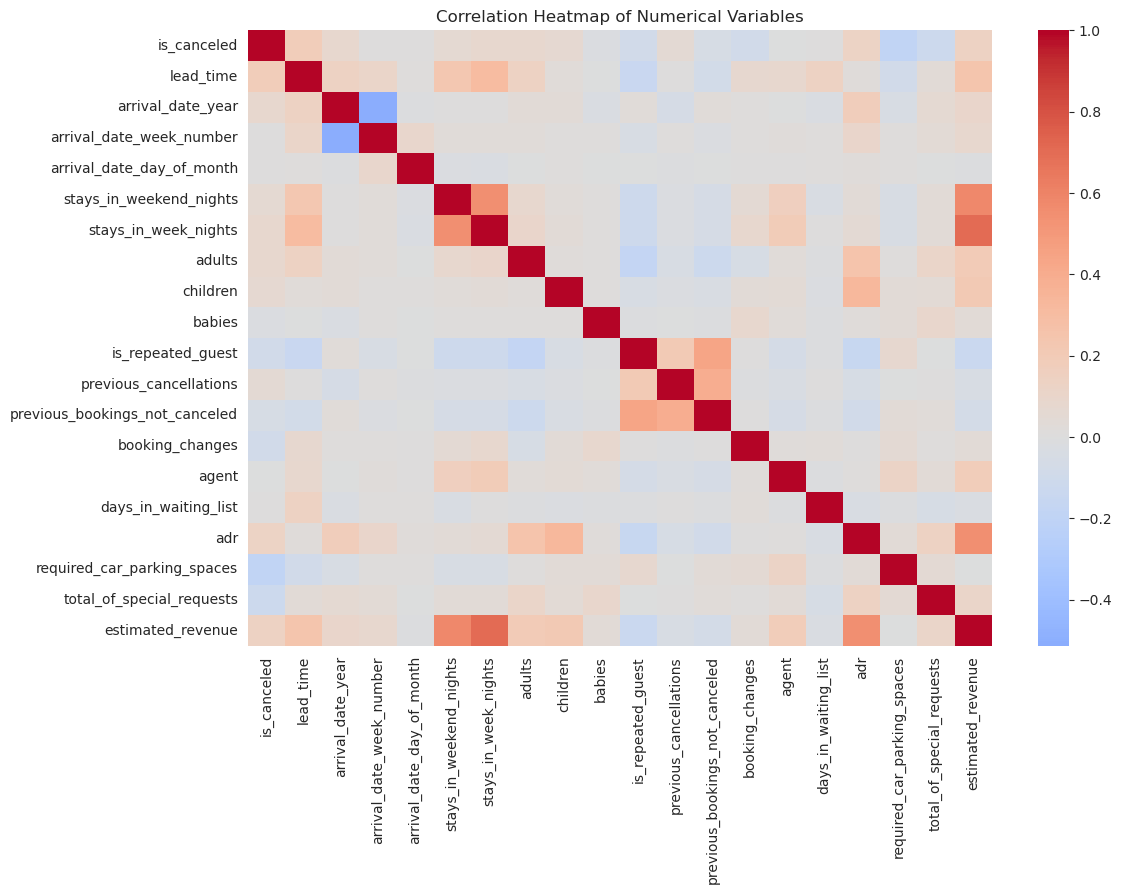

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

### Finding

Several booking characteristics show relationships with cancellation behavior, especially lead time and booking-related variables.

### Interpretation

Customers who book further in advance may have a higher likelihood of cancellation. Other variables show weaker relationships.

### Recommendation

Hotels should use booking characteristics to identify reservations that may require additional follow-up.

## 5.13 Booking Trends by Year

Analyzing yearly booking trends helps identify changes in demand over time and supports long-term planning.

In [43]:
yearly_bookings = (
    df_clean['arrival_date_year']
    .value_counts()
    .sort_index()
)

yearly_bookings

arrival_date_year
2015    13311
2016    42388
2017    31690
Name: count, dtype: int64

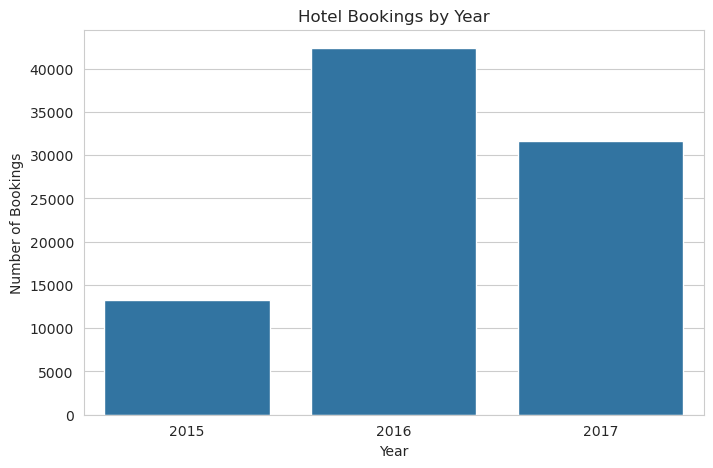

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_bookings.index,
    y=yearly_bookings.values
)

plt.title("Hotel Bookings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Bookings")

plt.show()

### Finding

Booking demand changes across years, showing differences in customer activity over time.

### Interpretation

Yearly booking patterns help hotels understand growth trends and changes in market demand.

### Recommendation

Hotels should:
- Monitor yearly demand changes.
- Adjust marketing strategies based on booking trends.
- Use historical data for future planning.

# 6. Business Insights and Final Recommendations

This section summarizes the main findings from the analysis and provides recommendations that hotels can use to improve operations, reduce risks, and increase revenue.

## Key Findings

### 1. Cancellation Behavior

- A significant number of reservations were cancelled.
- Bookings with longer lead times showed a higher tendency to be cancelled.
- Cancellations create uncertainty in occupancy planning and revenue forecasting.

### 2. Hotel Performance

- City Hotels received more bookings than Resort Hotels.
- Average Daily Rate (ADR) differs between hotel types, showing different pricing strategies and customer demand.

### 3. Customer Behavior

- Most bookings came from transient customers.
- Repeat guests represent a smaller percentage of total bookings, showing an opportunity to improve customer loyalty.

### 4. Booking Channels

- Online Travel Agencies (Online TA) were the largest source of bookings.
- Travel agencies and third-party platforms play an important role in hotel customer acquisition.

### 5. Seasonal Demand

- Booking volumes vary throughout the year.
- Peak months require better resource planning, while lower-demand periods present opportunities for promotions.

## Business Recommendations

Based on the analysis, hotels should consider the following actions:

### Reduce Cancellation Risk

- Identify high-risk reservations using booking characteristics such as lead time.
- Send reminders before arrival dates.
- Develop balanced cancellation policies.

### Improve Revenue Management

- Adjust room prices based on seasonal demand.
- Monitor ADR trends by hotel type and customer segment.
- Use historical booking patterns for pricing decisions.

### Increase Customer Retention

- Create loyalty programs for returning guests.
- Encourage direct bookings through incentives.
- Collect and analyze customer feedback.

### Optimize Marketing Strategy

- Maintain strong relationships with online travel agencies.
- Target promotions toward high-value customer markets.
- Customize offers based on customer origin and behavior.

## Conclusion

The Hotel Booking Demand Analysis provides insights into customer behavior, cancellation patterns, pricing, and booking trends.

By using data-driven decision-making, hotels can improve occupancy planning, reduce revenue losses from cancellations, optimize pricing strategies, and strengthen customer relationships.

In [46]:
%%writefile README.md

# Hotel Booking Demand Analysis

## Project Overview

This project analyzes hotel booking data to understand customer behavior, cancellation patterns, revenue impact, and booking trends.

The goal is to provide business insights that can help hotels improve revenue management, reduce cancellations, and optimize operations.

---

## Business Problem

Hotels need to understand booking behavior to reduce cancellations, improve revenue, and optimize hotel operations.

---

## Objectives

- Clean and prepare the dataset.
- Analyze booking trends.
- Investigate cancellation patterns.
- Study customer behavior.
- Generate business recommendations.

---

## Dataset

Hotel Booking Demand Dataset (Kaggle)

The dataset contains reservation information from City Hotels and Resort Hotels.

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## Analysis Performed

- Data cleaning
- Cancellation analysis
- Hotel performance analysis
- Customer behavior analysis
- Revenue impact analysis
- Booking trend analysis
- Correlation analysis

---

## Key Insights

- Cancellation behavior affects hotel revenue planning.
- Longer lead times are associated with higher cancellation risk.
- Online Travel Agencies are the main booking source.
- City Hotels receive more bookings than Resort Hotels.
- Booking demand changes by month.

---

## Business Recommendations

- Monitor high-risk reservations.
- Send reminders before arrival.
- Improve loyalty programs.
- Encourage direct bookings.
- Use seasonal pricing strategies.

---

## Author

Arista Kayirangwa

Overwriting README.md


# 7. Export Visualizations

The main charts from the analysis are saved as images for documentation and presentation on GitHub.

In [47]:
import os

os.makedirs("images", exist_ok=True)

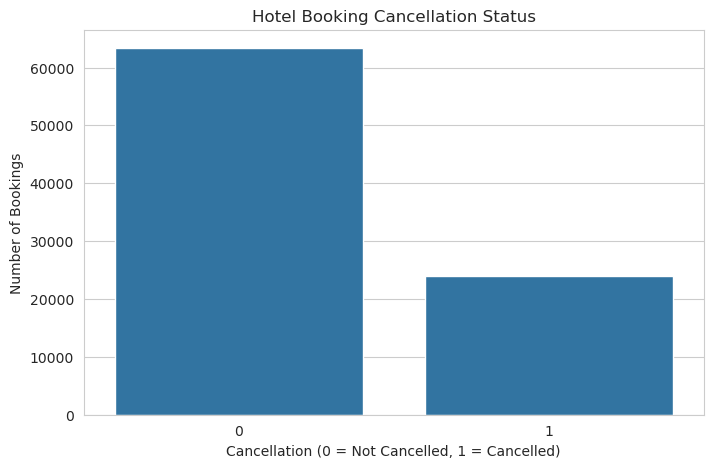

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='is_canceled'
)

plt.title("Hotel Booking Cancellation Status")
plt.xlabel("Cancellation (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Number of Bookings")

plt.savefig("images/cancellation_analysis.png", bbox_inches="tight")

plt.show()

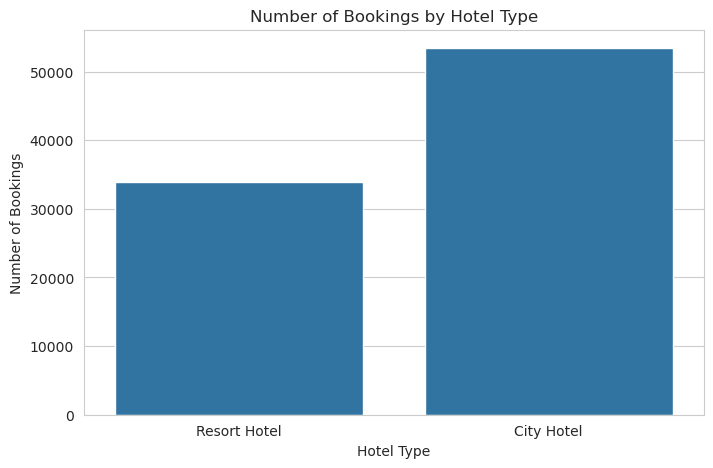

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='hotel'
)

plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.savefig("images/hotel_type_analysis.png", bbox_inches="tight")

plt.show()

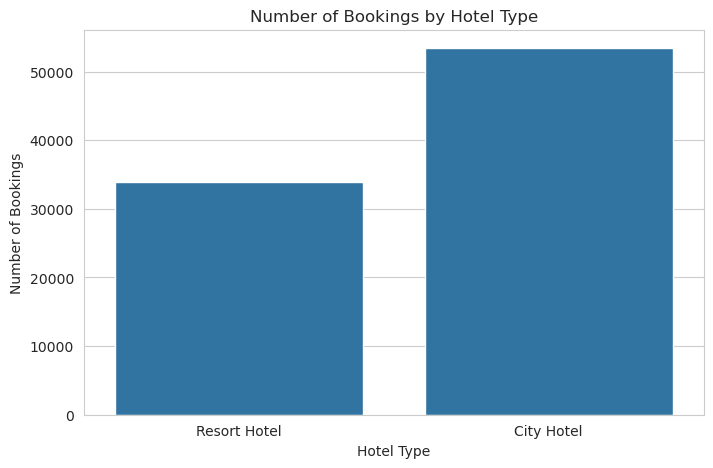

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='hotel'
)

plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.savefig("images/hotel_type_analysis.png", bbox_inches="tight")

plt.show()

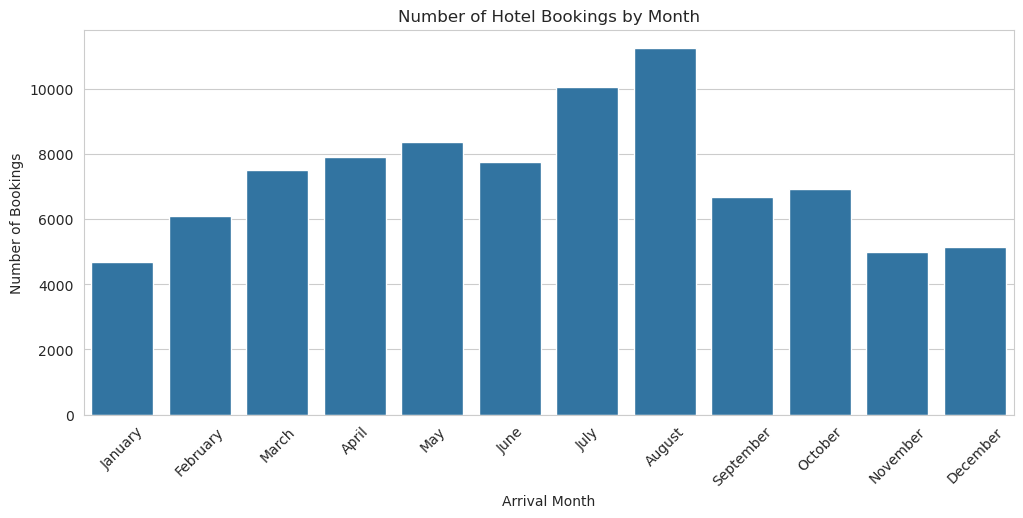

In [51]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_bookings.index,
    y=monthly_bookings.values
)

plt.title("Number of Hotel Bookings by Month")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.savefig("images/monthly_booking_trends.png", bbox_inches="tight")

plt.show()

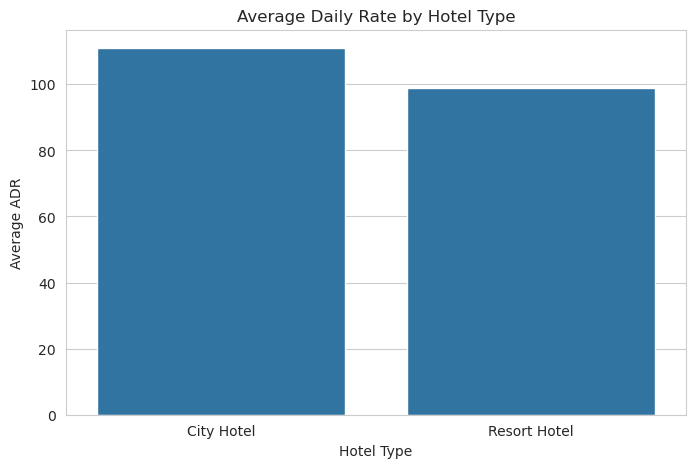

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=average_adr.index,
    y=average_adr.values
)

plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")

plt.savefig("images/adr_analysis.png", bbox_inches="tight")

plt.show()

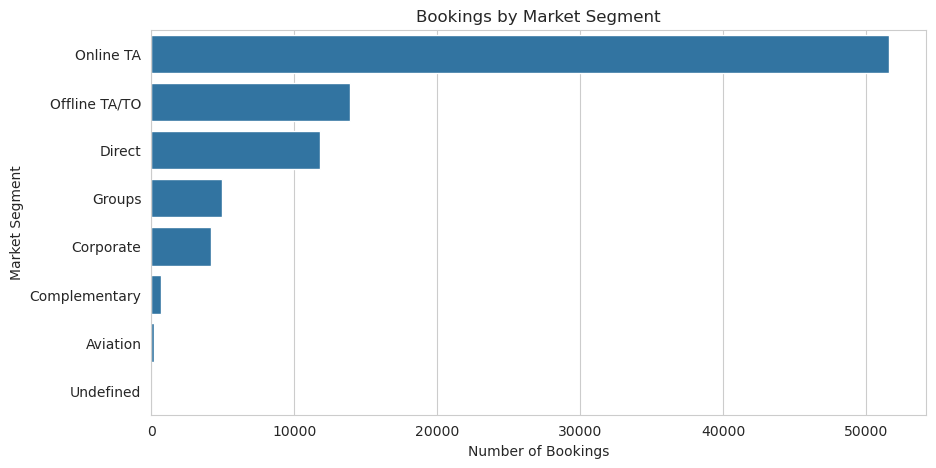

In [53]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=market_segment.values,
    y=market_segment.index
)

plt.title("Bookings by Market Segment")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")

plt.savefig("images/market_segment_analysis.png", bbox_inches="tight")

plt.show()

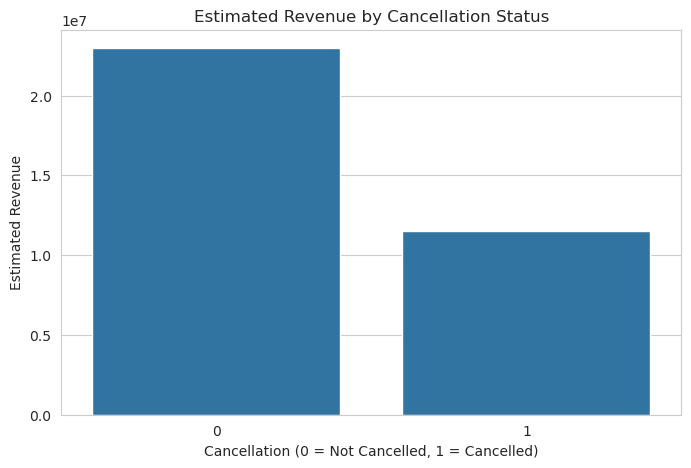

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=revenue_by_status.index,
    y=revenue_by_status.values
)

plt.title("Estimated Revenue by Cancellation Status")
plt.xlabel("Cancellation (0 = Not Cancelled, 1 = Cancelled)")
plt.ylabel("Estimated Revenue")

plt.savefig("images/revenue_impact_analysis.png", bbox_inches="tight")

plt.show()

# Project Conclusion

This analysis explored hotel booking patterns, cancellation behavior, customer characteristics, pricing trends, and revenue impact.

The findings provide insights that can help hotels reduce cancellation risks, improve revenue management, optimize marketing strategies, and better plan operations.